# QPE Calibration Decision Map on H2

This benchmark turns the raw QPE calibration sweep into a configuration map for choosing practical H2 QPE settings.

It reports:

- absolute energy error against an exact H2 reference
- dominant-bitstring and branch-selection diagnostics
- best-configuration tables
- a default-adequacy summary for the package baseline settings

The goal is not to add another broad sweep. The goal is to make the existing calibration question answerable: which settings are good enough, which settings are risky, and why.

## Configuration

The default grid is intentionally modest so the notebook can be rerun during development. Expand `ANCILLA_GRID`, `TIME_GRID`, `TROTTER_GRID`, `SHOT_GRID`, or `SEEDS` when you want a denser map.

`shots=None` uses analytic probabilities and is run once per structural configuration. Finite-shot settings are repeated across seeds.

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

from common import (
    analyze_qpe_result,
    get_exact_spectrum,
    qpe_calibration_plan,
    timed_call,
)
from qpe import run_qpe

MOLECULE = "H2"
MAPPING = "jordan_wigner"

ANCILLA_GRID = [2, 3, 4, 5]
TIME_GRID = [0.5, 1.0, 2.0, 4.0]
TROTTER_GRID = [1, 2, 4]
SHOT_GRID = [None, 500, 1000, 2000]
SEEDS = [0, 1, 2]

DEFAULT_CONFIG = {
    "ancillas": 4,
    "t": 1.0,
    "trotter_steps": 2,
    "shots": 1000,
}

GOOD_ENOUGH_ERROR_HA = 0.05
STRONG_ERROR_HA = 0.01

EXACT_GROUND = float(get_exact_spectrum(MOLECULE, k=1, mapping=MAPPING)[0])
print(f"Exact {MOLECULE} ground energy: {EXACT_GROUND:.10f} Ha")

Exact H2 ground energy: -1.1372701749 Ha


In [2]:
plan = qpe_calibration_plan(
    ancillas_grid=ANCILLA_GRID,
    times_grid=TIME_GRID,
    trotter_grid=TROTTER_GRID,
    shots_grid=SHOT_GRID,
    seeds=SEEDS,
)
print(f"Planned QPE runs: {len(plan)}")
display(pd.DataFrame(plan).head(12))

Planned QPE runs: 480


,ancillas,t,trotter_steps,shots,seed
0,2,0.5,1,NaN,0
1,2,0.5,1,500.0,0
2,2,0.5,1,500.0,1
3,2,0.5,1,500.0,2
4,2,0.5,1,1000.0,0
5,2,0.5,1,1000.0,1
6,2,0.5,1,1000.0,2
7,2,0.5,1,2000.0,0
8,2,0.5,1,2000.0,1
9,2,0.5,1,2000.0,2


## Run Calibration Map

The package cache is enabled with `force=False`. Re-running this notebook should be much faster after the first full pass, while stale cache entries without runtime metadata are automatically refreshed by the public runner.

In [3]:
records = []
progress_every = max(1, len(plan) // 12)

for index, cfg in enumerate(plan, start=1):
    if index == 1 or index % progress_every == 0 or index == len(plan):
        print(
            f"[{index}/{len(plan)}] "
            f"a={cfg['ancillas']} | t={cfg['t']} | r={cfg['trotter_steps']} | "
            f"shots={cfg['shots']} | seed={cfg['seed']}"
        )

    result, api_runtime_s = timed_call(
        run_qpe,
        suppress_stdout=True,
        molecule=MOLECULE,
        mapping=MAPPING,
        n_ancilla=cfg["ancillas"],
        t=cfg["t"],
        trotter_steps=cfg["trotter_steps"],
        shots=cfg["shots"],
        seed=cfg["seed"],
        noisy=False,
        plot=False,
        force=False,
    )
    diagnostics = analyze_qpe_result(
        result,
        EXACT_GROUND,
        good_enough_error_ha=GOOD_ENOUGH_ERROR_HA,
    )
    records.append(
        {
            **cfg,
            "shot_mode": "analytic" if cfg["shots"] is None else "sampled",
            "cache_hit": bool(result.get("cache_hit", False)),
            "api_runtime_s": float(api_runtime_s),
            "compute_runtime_s": float(result.get("compute_runtime_s", api_runtime_s)),
            "num_qubits": int(result["num_qubits"]),
            "total_wires": int(result["num_qubits"] + cfg["ancillas"]),
            **diagnostics,
        }
    )

runs_df = pd.DataFrame(records)
print(f"Completed {len(runs_df)} QPE runs.")
display(
    runs_df.sort_values(["abs_error", "compute_runtime_s"])
    .head(15)[
        [
            "ancillas",
            "t",
            "trotter_steps",
            "shots",
            "seed",
            "energy",
            "abs_error",
            "best_bitstring",
            "best_probability",
            "oracle_any_abs_error",
            "branch_selection_failure",
            "dominant_bin_failure",
            "resolution_or_alias_failure",
            "cache_hit",
        ]
    ]
    .round(8)
)

[1/480] a=2 | t=0.5 | r=1 | shots=None | seed=0


[40/480] a=2 | t=1.0 | r=1 | shots=2000 | seed=2
[80/480] a=2 | t=2.0 | r=2 | shots=2000 | seed=2
[120/480] a=2 | t=4.0 | r=4 | shots=2000 | seed=2
[160/480] a=3 | t=1.0 | r=1 | shots=2000 | seed=2
[200/480] a=3 | t=2.0 | r=2 | shots=2000 | seed=2
[240/480] a=3 | t=4.0 | r=4 | shots=2000 | seed=2
[280/480] a=4 | t=1.0 | r=1 | shots=2000 | seed=2
[320/480] a=4 | t=2.0 | r=2 | shots=2000 | seed=2
[360/480] a=4 | t=4.0 | r=4 | shots=2000 | seed=2
[400/480] a=5 | t=1.0 | r=1 | shots=2000 | seed=2
[440/480] a=5 | t=2.0 | r=2 | shots=2000 | seed=2
[480/480] a=5 | t=4.0 | r=4 | shots=2000 | seed=2
Completed 480 QPE runs.


,ancillas,t,trotter_steps,shots,seed,energy,abs_error,best_bitstring,best_probability,oracle_any_abs_error,branch_selection_failure,dominant_bin_failure,resolution_or_alias_failure,cache_hit
90,2,4.0,1,NaN,0,-1.178097,0.040827,11,0.513338,0.040827,False,False,False,True
92,2,4.0,1,500.0,1,-1.178097,0.040827,11,0.542000,0.040827,False,False,False,True
91,2,4.0,1,500.0,0,-1.178097,0.040827,11,0.498000,0.040827,False,False,False,True
93,2,4.0,1,500.0,2,-1.178097,0.040827,11,0.494000,0.040827,False,False,False,True
94,2,4.0,1,1000.0,0,-1.178097,0.040827,11,0.520000,0.040827,False,False,False,True
96,2,4.0,1,1000.0,2,-1.178097,0.040827,11,0.516000,0.040827,False,False,False,True
97,2,4.0,1,2000.0,0,-1.178097,0.040827,11,0.521500,0.040827,False,False,False,True
95,2,4.0,1,1000.0,1,-1.178097,0.040827,11,0.518000,0.040827,False,False,False,True
99,2,4.0,1,2000.0,2,-1.178097,0.040827,11,0.505000,0.040827,False,False,False,True
98,2,4.0,1,2000.0,1,-1.178097,0.040827,11,0.512000,0.040827,False,False,False,True


## Best Configuration Table

This table ranks structural configurations after aggregating across seeds. The score prioritizes low mean error, then penalizes seed spread, branch/bin failure rates, and compute cost. The weights are deliberately simple so they are easy to adjust for a different tolerance target.

In [4]:
def failure_rate(series: pd.Series) -> float:
    return float(series.astype(bool).mean())


summary_df = (
    runs_df.groupby(["ancillas", "t", "trotter_steps", "shots"], dropna=False)
    .agg(
        n_runs=("abs_error", "size"),
        mean_abs_error=("abs_error", "mean"),
        std_abs_error=("abs_error", "std"),
        max_abs_error=("abs_error", "max"),
        best_abs_error=("abs_error", "min"),
        mean_oracle_abs_error=("oracle_any_abs_error", "mean"),
        mean_bin_width_energy_ha=("bin_width_energy_ha", "mean"),
        mean_best_probability=("best_probability", "mean"),
        mean_compute_runtime_s=("compute_runtime_s", "mean"),
        branch_failure_rate=("branch_selection_failure", failure_rate),
        dominant_bin_failure_rate=("dominant_bin_failure", failure_rate),
        resolution_or_alias_failure_rate=("resolution_or_alias_failure", failure_rate),
    )
    .reset_index()
)
summary_df["std_abs_error"] = summary_df["std_abs_error"].fillna(0.0)
summary_df["shots_label"] = summary_df["shots"].map(lambda x: "analytic" if pd.isna(x) else str(int(x)))
summary_df["score"] = (
    summary_df["mean_abs_error"]
    + 0.25 * summary_df["std_abs_error"]
    + 0.50 * summary_df["branch_failure_rate"]
    + 0.50 * summary_df["dominant_bin_failure_rate"]
    + 0.25 * summary_df["resolution_or_alias_failure_rate"]
    + 0.0005 * summary_df["mean_compute_runtime_s"]
)
summary_df = summary_df.sort_values(
    ["score", "mean_abs_error", "max_abs_error", "mean_compute_runtime_s"]
)

best_configs = summary_df.head(20)
display(
    best_configs[
        [
            "ancillas",
            "t",
            "trotter_steps",
            "shots_label",
            "mean_abs_error",
            "std_abs_error",
            "max_abs_error",
            "mean_oracle_abs_error",
            "mean_bin_width_energy_ha",
            "branch_failure_rate",
            "dominant_bin_failure_rate",
            "resolution_or_alias_failure_rate",
            "mean_compute_runtime_s",
            "score",
        ]
    ].round(8)
)

,ancillas,t,trotter_steps,shots_label,mean_abs_error,std_abs_error,max_abs_error,mean_oracle_abs_error,mean_bin_width_energy_ha,branch_failure_rate,dominant_bin_failure_rate,resolution_or_alias_failure_rate,mean_compute_runtime_s,score
39,2,4.0,1,analytic,0.040827,0.0,0.040827,0.040827,0.392699,0.0,0.0,0.0,0.076394,0.040865
36,2,4.0,1,500,0.040827,0.0,0.040827,0.040827,0.392699,0.0,0.0,0.0,0.084816,0.040869
37,2,4.0,1,1000,0.040827,0.0,0.040827,0.040827,0.392699,0.0,0.0,0.0,0.092987,0.040874
38,2,4.0,1,2000,0.040827,0.0,0.040827,0.040827,0.392699,0.0,0.0,0.0,0.101829,0.040878
43,2,4.0,2,analytic,0.040827,0.0,0.040827,0.040827,0.392699,0.0,0.0,0.0,0.106913,0.040881
40,2,4.0,2,500,0.040827,0.0,0.040827,0.040827,0.392699,0.0,0.0,0.0,0.110669,0.040882
87,3,4.0,1,analytic,0.040827,0.0,0.040827,0.040827,0.196350,0.0,0.0,0.0,0.112833,0.040883
84,3,4.0,1,500,0.040827,0.0,0.040827,0.040827,0.196350,0.0,0.0,0.0,0.120086,0.040887
41,2,4.0,2,1000,0.040827,0.0,0.040827,0.040827,0.392699,0.0,0.0,0.0,0.126221,0.040890
42,2,4.0,2,2000,0.040827,0.0,0.040827,0.040827,0.392699,0.0,0.0,0.0,0.126231,0.040890


## Default Adequacy

The package baseline is evaluated against the same criteria as the rest of the grid. Use this section to decide whether the default is strong enough for small H2 demonstrations or whether a benchmark should retune QPE explicitly.

In [5]:
default_mask = (
    (summary_df["ancillas"] == DEFAULT_CONFIG["ancillas"])
    & (summary_df["t"] == DEFAULT_CONFIG["t"])
    & (summary_df["trotter_steps"] == DEFAULT_CONFIG["trotter_steps"])
    & (summary_df["shots"].fillna(-1).astype(int) == int(DEFAULT_CONFIG["shots"]))
)

default_rows = summary_df.loc[default_mask].copy()
if default_rows.empty:
    display(Markdown("**Default config was not included in the current grid.**"))
else:
    default_row = default_rows.iloc[0]
    default_rank = int(summary_df.index.get_loc(default_row.name) + 1)
    n_configs = int(len(summary_df))
    default_is_good_enough = bool(
        default_row["mean_abs_error"] <= GOOD_ENOUGH_ERROR_HA
        and default_row["branch_failure_rate"] == 0.0
        and default_row["dominant_bin_failure_rate"] == 0.0
    )
    default_is_strong = bool(
        default_row["mean_abs_error"] <= STRONG_ERROR_HA
        and default_row["max_abs_error"] <= GOOD_ENOUGH_ERROR_HA
        and default_row["branch_failure_rate"] == 0.0
        and default_row["dominant_bin_failure_rate"] == 0.0
    )
    verdict = "strong" if default_is_strong else "good enough" if default_is_good_enough else "needs retuning"
    display(
        Markdown(
            f"**Default verdict:** `{verdict}`. "
            f"Rank `{default_rank}` of `{n_configs}` tested configurations by score. "
            f"Mean absolute error is `{default_row['mean_abs_error']:.6f}` Ha."
        )
    )
    display(
        default_rows[
            [
                "ancillas",
                "t",
                "trotter_steps",
                "shots_label",
                "mean_abs_error",
                "std_abs_error",
                "max_abs_error",
                "branch_failure_rate",
                "dominant_bin_failure_rate",
                "resolution_or_alias_failure_rate",
                "mean_compute_runtime_s",
                "score",
            ]
        ].round(8)
    )

**Default verdict:** `good enough`. Rank `39` of `192` tested configurations by score. Mean absolute error is `0.040827` Ha.

,ancillas,t,trotter_steps,shots_label,mean_abs_error,std_abs_error,max_abs_error,branch_failure_rate,dominant_bin_failure_rate,resolution_or_alias_failure_rate,mean_compute_runtime_s,score
113,4,1.0,2,1000,0.040827,0.0,0.040827,0.0,0.0,0.0,0.342122,0.040998


## Failure Diagnostics

These tables separate three failure modes:

- `branch_selection_failure`: the selected dominant bitstring had a better MSB/LSB branch than the one selected by the package's HF-reference heuristic.
- `dominant_bin_failure`: some other measured bitstring would have produced a lower exact-reference error than the dominant bitstring.
- `resolution_or_alias_failure`: even the best observed bitstring/branch missed the target tolerance, which usually means the grid needs more phase resolution, a different evolution time, or a different preparation/reference strategy.

In [6]:
failure_cols = [
    "ancillas",
    "t",
    "trotter_steps",
    "shots",
    "seed",
    "energy",
    "abs_error",
    "best_bitstring",
    "best_probability",
    "oracle_any_bitstring",
    "oracle_any_orientation",
    "oracle_any_energy",
    "oracle_any_abs_error",
    "branch_selection_failure",
    "dominant_bin_failure",
    "resolution_or_alias_failure",
]

failures_df = runs_df[
    runs_df[
        [
            "branch_selection_failure",
            "dominant_bin_failure",
            "resolution_or_alias_failure",
        ]
    ].any(axis=1)
].sort_values(["abs_error", "oracle_any_abs_error"])

print(f"Failure-diagnostic rows: {len(failures_df)}")
display(failures_df[failure_cols].head(30).round(8))

failure_summary = (
    runs_df.groupby(["ancillas", "t", "trotter_steps"], dropna=False)
    .agg(
        n_runs=("abs_error", "size"),
        mean_abs_error=("abs_error", "mean"),
        branch_failure_rate=("branch_selection_failure", failure_rate),
        dominant_bin_failure_rate=("dominant_bin_failure", failure_rate),
        resolution_or_alias_failure_rate=("resolution_or_alias_failure", failure_rate),
        mean_bin_width_energy_ha=("bin_width_energy_ha", "mean"),
    )
    .reset_index()
    .sort_values(
        [
            "resolution_or_alias_failure_rate",
            "dominant_bin_failure_rate",
            "branch_failure_rate",
            "mean_abs_error",
        ],
        ascending=[False, False, False, False],
    )
)

display(failure_summary.head(20).round(8))

Failure-diagnostic rows: 340


,ancillas,t,trotter_steps,shots,seed,energy,abs_error,best_bitstring,best_probability,oracle_any_bitstring,oracle_any_orientation,oracle_any_energy,oracle_any_abs_error,branch_selection_failure,dominant_bin_failure,resolution_or_alias_failure
350,4,4.0,4,NaN,0,-1.079922,0.057348,1011,0.452694,0011,lsb,-1.178097,0.040827,False,True,False
351,4,4.0,4,500.0,0,-1.079922,0.057348,1011,0.444000,0011,lsb,-1.178097,0.040827,False,True,False
352,4,4.0,4,500.0,1,-1.079922,0.057348,1011,0.486000,0011,lsb,-1.178097,0.040827,False,True,False
353,4,4.0,4,500.0,2,-1.079922,0.057348,1011,0.472000,1100,msb,-1.178097,0.040827,False,True,False
354,4,4.0,4,1000.0,0,-1.079922,0.057348,1011,0.456000,0011,lsb,-1.178097,0.040827,False,True,False
355,4,4.0,4,1000.0,1,-1.079922,0.057348,1011,0.461000,0011,lsb,-1.178097,0.040827,False,True,False
356,4,4.0,4,1000.0,2,-1.079922,0.057348,1011,0.472000,0011,lsb,-1.178097,0.040827,False,True,False
357,4,4.0,4,2000.0,0,-1.079922,0.057348,1011,0.454500,0011,lsb,-1.178097,0.040827,False,True,False
358,4,4.0,4,2000.0,1,-1.079922,0.057348,1011,0.454500,0011,lsb,-1.178097,0.040827,False,True,False
359,4,4.0,4,2000.0,2,-1.079922,0.057348,1011,0.454000,0011,lsb,-1.178097,0.040827,False,True,False


,ancillas,t,trotter_steps,n_runs,mean_abs_error,branch_failure_rate,dominant_bin_failure_rate,resolution_or_alias_failure_rate,mean_bin_width_energy_ha
0,2,0.5,1,10,1.137270,0.0,0.0,1.0,3.141593
1,2,0.5,2,10,1.137270,0.0,0.0,1.0,3.141593
2,2,0.5,4,10,1.137270,0.0,0.0,1.0,3.141593
3,2,1.0,1,10,0.433526,0.0,0.0,1.0,1.570796
4,2,1.0,2,10,0.433526,0.0,0.0,1.0,1.570796
5,2,1.0,4,10,0.433526,0.0,0.0,1.0,1.570796
12,3,0.5,1,10,0.433526,0.0,0.0,1.0,1.570796
13,3,0.5,2,10,0.433526,0.0,0.0,1.0,1.570796
14,3,0.5,4,10,0.433526,0.0,0.0,1.0,1.570796
6,2,2.0,1,10,0.351872,0.0,0.0,1.0,0.785398


## Visual Map

The heatmap shows the best mean absolute error found for each ancilla/time pair after minimizing over Trotter depth and shot count. Use it to spot broad stable regions instead of overfitting to a single row in the table.

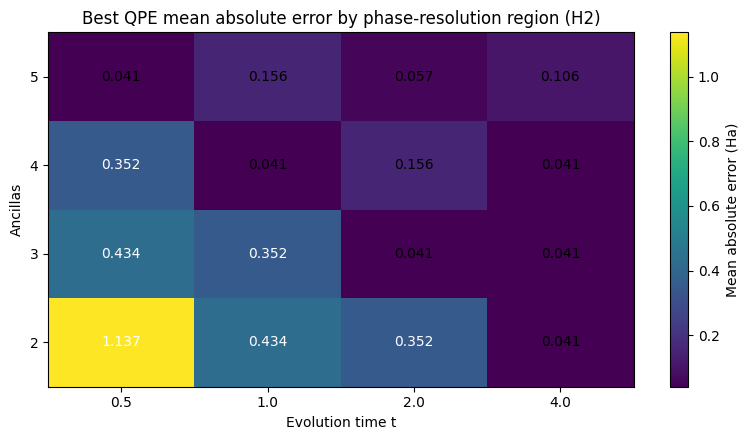

In [7]:
heatmap_source = (
    summary_df.groupby(["ancillas", "t"], as_index=False)
    .agg(best_mean_abs_error=("mean_abs_error", "min"))
)
heatmap = heatmap_source.pivot(index="ancillas", columns="t", values="best_mean_abs_error")

fig, ax = plt.subplots(figsize=(8, 4.5))
im = ax.imshow(heatmap.to_numpy(dtype=float), aspect="auto", origin="lower")
ax.set_xticks(range(len(heatmap.columns)))
ax.set_xticklabels([str(x) for x in heatmap.columns])
ax.set_yticks(range(len(heatmap.index)))
ax.set_yticklabels([str(x) for x in heatmap.index])
ax.set_xlabel("Evolution time t")
ax.set_ylabel("Ancillas")
ax.set_title(f"Best QPE mean absolute error by phase-resolution region ({MOLECULE})")
fig.colorbar(im, ax=ax, label="Mean absolute error (Ha)")

for i, ancillas in enumerate(heatmap.index):
    for j, t in enumerate(heatmap.columns):
        value = heatmap.loc[ancillas, t]
        ax.text(j, i, f"{value:.3f}", ha="center", va="center", color="white" if value > heatmap.to_numpy().mean() else "black")

plt.tight_layout()
plt.show()

## Decision Summary

This cell converts the tables into concise notebook conclusions. Re-run the notebook after changing the grid so the summary stays tied to the actual calibration data.

In [8]:
best_row = summary_df.iloc[0]
robust_candidates = summary_df[
    (summary_df["mean_abs_error"] <= GOOD_ENOUGH_ERROR_HA)
    & (summary_df["max_abs_error"] <= 2 * GOOD_ENOUGH_ERROR_HA)
    & (summary_df["branch_failure_rate"] == 0.0)
    & (summary_df["dominant_bin_failure_rate"] == 0.0)
].copy()

if robust_candidates.empty:
    robust_text = "No tested configuration met the robust good-enough criteria. Expand the grid or retune QPE for this target."
else:
    sort_col = "total_wires" if "total_wires" in robust_candidates.columns else "ancillas"
    robust = robust_candidates.sort_values([sort_col, "score"]).iloc[0]
    robust_text = (
        "Smallest robust candidate: "
        f"ancillas={int(robust['ancillas'])}, t={robust['t']}, "
        f"trotter_steps={int(robust['trotter_steps'])}, shots={robust['shots_label']} "
        f"with mean_abs_error={robust['mean_abs_error']:.6f} Ha."
    )

summary_lines = [
    f"Best tested configuration by score: ancillas={int(best_row['ancillas'])}, t={best_row['t']}, trotter_steps={int(best_row['trotter_steps'])}, shots={best_row['shots_label']}.",
    f"Best mean absolute error: {best_row['mean_abs_error']:.6f} Ha; max error across seeds: {best_row['max_abs_error']:.6f} Ha.",
    robust_text,
]

if not default_rows.empty:
    summary_lines.append(
        f"Package default ({DEFAULT_CONFIG}) verdict: {verdict}; mean_abs_error={default_row['mean_abs_error']:.6f} Ha."
    )

if len(failures_df) == 0:
    summary_lines.append("No branch, dominant-bin, or resolution/alias failures were detected under the configured thresholds.")
else:
    summary_lines.append(
        f"Detected {len(failures_df)} diagnostic failure rows. Inspect the failure tables before adopting settings from affected regions."
    )

display(Markdown("\n".join(f"- {line}" for line in summary_lines)))

- Best tested configuration by score: ancillas=2, t=4.0, trotter_steps=1, shots=analytic.
- Best mean absolute error: 0.040827 Ha; max error across seeds: 0.040827 Ha.
- Smallest robust candidate: ancillas=2, t=4.0, trotter_steps=1, shots=analytic with mean_abs_error=0.040827 Ha.
- Package default ({'ancillas': 4, 't': 1.0, 'trotter_steps': 2, 'shots': 1000}) verdict: good enough; mean_abs_error=0.040827 Ha.
- Detected 340 diagnostic failure rows. Inspect the failure tables before adopting settings from affected regions.